<a href="https://colab.research.google.com/github/Dustin-Nguyen-312/thuchanhdeeplearning/blob/main/DeepLearning_Tu%E1%BA%A7n3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import sys

# Cài đặt thư viện kagglehub và opencv-python
!{sys.executable} -m pip install kagglehub opencv-python scikit-learn

In [24]:
import kagglehub
import os

# Tải bộ dữ liệu chó và mèo
# Đường dẫn này sẽ là thư mục gốc chứa các thư mục con 'train' và 'test'
dataset_path = kagglehub.dataset_download("bhavikjikadara/dog-and-cat-classification-dataset")

print(f"Đường dẫn đến các tệp dữ liệu đã tải xuống: {dataset_path}")

100%|██████████| 775M/775M [00:10<00:00, 78.8MB/s]

Extracting files...


Đường dẫn đến các tệp dữ liệu đã tải xuống: /root/.cache/kagglehub/datasets/bhavikjikadara/dog-and-cat-classification-dataset/versions/1


In [29]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split

# Hàm để tải hình ảnh và nhãn từ một thư mục
def load_images_from_subfolders(base_folder_path, img_size=(32, 32)):
    images = []
    labels = []
    # Giả định có các thư mục con 'Cat' và 'Dog' bên trong base_folder_path
    class_mapping = {'Cat': 0, 'Dog': 1} # Mèo là 0, Chó là 1

    for class_name, class_label in class_mapping.items():
        class_dir = os.path.join(base_folder_path, class_name)
        if not os.path.exists(class_dir):
            print(f"Thư mục {class_dir} không tìm thấy. Bỏ qua.")
            continue
        for filename in os.listdir(class_dir):
            img_path = os.path.join(class_dir, filename)
            if img_path.endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                try:
                    img = cv2.imread(img_path)
                    if img is not None:
                        # Đổi kích thước ảnh để phù hợp với mô hình CIFAR-10 ban đầu
                        img = cv2.resize(img, img_size)
                        images.append(img)
                        labels.append(class_label)
                except Exception as e:
                    print(f"Lỗi khi tải ảnh {img_path}: {e}")
    return np.array(images), np.array(labels)

print(f"Đang tải dữ liệu từ đường dẫn: {dataset_path}")

# Đường dẫn thực tế đến các hình ảnh là dataset_path/PetImages/
data_folder = os.path.join(dataset_path, 'PetImages')

# Tải tất cả dữ liệu có sẵn
X_all, y_all = load_images_from_subfolders(data_folder)

# Kiểm tra nếu X_all rỗng để tránh lỗi
if X_all.size == 0:
    print("Lỗi: Không tìm thấy ảnh nào để tải. Vui lòng kiểm tra đường dẫn và nội dung thư mục.")
    X_train = np.array([])
    y_train = np.array([], dtype=int).reshape(-1, 1)
    X_test = np.array([])
    y_test = np.array([], dtype=int).reshape(-1, 1)
    X_train_flat = np.array([])
    X_test_flat = np.array([])
else:
    # Chia dữ liệu thành tập huấn luyện và kiểm tra (ví dụ 80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(
        X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
    )

    # Đảm bảo các nhãn có hình dạng (N, 1) cho sparse_categorical_crossentropy
    y_train = y_train.reshape(-1, 1)
    y_test = y_test.reshape(-1, 1)

    # 1. Kéo phẳng ảnh từ ma trận 3D (32x32x3) thành vector 1D dài 3072 phần tử
    X_train_flat = X_train.reshape(X_train.shape[0], -1)
    X_test_flat = X_test.reshape(X_test.shape[0], -1)

    # 2. Chuẩn hóa giá trị các ô màu từ [0, 255] về đoạn [0, 1] cho mạng dễ học
    X_train_flat = X_train_flat / 255.0
    X_test_flat = X_test_flat / 255.0

print("--- Tải dữ liệu mới thành công! ---")
print("Kích thước tập ảnh dùng để HỌC (X_train):", X_train.shape)
print("Kích thước tập nhãn dùng để HỌC (y_train):", y_train.shape)
print("Kích thước tập ảnh dùng để KIỂM TRA (X_test):", X_test.shape)
print("Kích thước tập nhãn dùng để KIỂM TRA (y_test):", y_test.shape)
print("Kích thước dữ liệu phẳng dùng để HỌC (X_train_flat):", X_train_flat.shape)
print("Kích thước dữ liệu phẳng dùng để KIỂM TRA (X_test_flat):", X_test_flat.shape)

Đang tải dữ liệu từ đường dẫn: /root/.cache/kagglehub/datasets/bhavikjikadara/dog-and-cat-classification-dataset/versions/1
--- Tải dữ liệu mới thành công! ---
Kích thước tập ảnh dùng để HỌC (X_train): (19997, 32, 32, 3)
Kích thước tập nhãn dùng để HỌC (y_train): (19997, 1)
Kích thước tập ảnh dùng để KIỂM TRA (X_test): (5000, 32, 32, 3)
Kích thước tập nhãn dùng để KIỂM TRA (y_test): (5000, 1)
Kích thước dữ liệu phẳng dùng để HỌC (X_train_flat): (19997, 3072)
Kích thước dữ liệu phẳng dùng để KIỂM TRA (X_test_flat): (5000, 3072)


MỘT SỐ HÌNH ẢNH TỪ TẬP HUẤN LUYỆN:


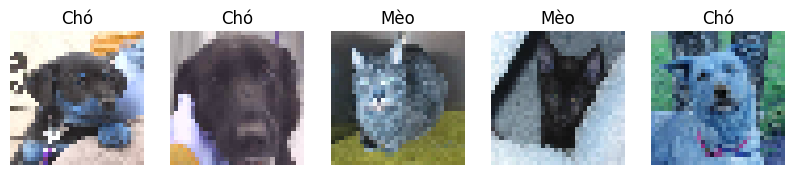


MỘT SỐ HÌNH ẢNH TỪ TẬP KIỂM TRA:


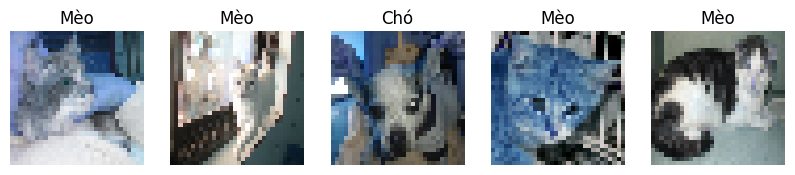

In [34]:
import matplotlib.pyplot as plt
import random

class_names = ['Mèo', 'Chó']

# Display a few training images
print('MỘT SỐ HÌNH ẢNH TỪ TẬP HUẤN LUYỆN:')
plt.figure(figsize=(10, 5))
for i in range(5):
    index = random.randint(0, len(X_train) - 1)
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_train[index].astype('uint8'))
    plt.title(class_names[y_train[index][0]])
    plt.axis('off')
plt.show()

# Display a few test images
print('\nMỘT SỐ HÌNH ẢNH TỪ TẬP KIỂM TRA:')
plt.figure(figsize=(10, 5))
for i in range(5):
    index = random.randint(0, len(X_test) - 1)
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[index].astype('uint8'))
    plt.title(class_names[y_test[index][0]])
    plt.axis('off')
plt.show()

In [30]:
# Cell này đã được làm trống vì các bước làm phẳng và chuẩn hóa đã được chuyển vào cell tải dữ liệu.

In [43]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LeakyReLU
from tensorflow.keras.optimizers import Adam
import numpy as np

# BƯỚC 1: THIẾT KẾ MẠNG ANN
input_dim = X_train_flat.shape[1]

animal_model = Sequential()

# Tầng đầu vào và tầng ẩn đầu tiên: Tăng số neuron
animal_model.add(Dense(512, input_dim=input_dim))
animal_model.add(LeakyReLU(alpha=0.1))
animal_model.add(Dropout(0.45)) # Điều chỉnh Dropout

# Tầng ẩn thứ hai: Tăng số neuron
animal_model.add(Dense(256))
animal_model.add(LeakyReLU(alpha=0.1))
animal_model.add(Dropout(0.35)) # Điều chỉnh Dropout

# Tầng ẩn thứ ba: Tăng số neuron
animal_model.add(Dense(128))
animal_model.add(LeakyReLU(alpha=0.1))
animal_model.add(Dropout(0.25)) # Điều chỉnh Dropout

# Tầng đầu ra (2 lớp: mèo, chó)
animal_model.add(Dense(2, activation='softmax'))

# BƯỚC 2: CẤU HÌNH OPTIMIZER VỚI LEARNING RATE TỐI ƯU
custom_optimizer = Adam(learning_rate=0.0003) # Điều chỉnh Learning Rate

animal_model.compile(
    optimizer=custom_optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Tóm tắt cấu trúc mô hình
animal_model.summary()

# BƯỚC 3: HUẤN LUYỆN
history = animal_model.fit(
    X_train_flat, y_train,
    epochs=50, # Đã điều chỉnh lại số epoch về 50 theo yêu cầu
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_32 (Dense)                │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_19 (LeakyReLU)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_20 (LeakyReLU)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_21 (LeakyReLU)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,737,858 (6.63 MB)

 Trainable params: 1,737,858 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step - accuracy: 0.5125 - loss: 0.7242 - val_accuracy: 0.5190 - val_loss: 0.6903
Epoch 2/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 0.5375 - loss: 0.6941 - val_accuracy: 0.5835 - val_loss: 0.6799
Epoch 3/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.5600 - loss: 0.6830 - val_accuracy: 0.5625 - val_loss: 0.6798
Epoch 4/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.5755 - loss: 0.6739 - val_accuracy: 0.5800 - val_loss: 0.6729
Epoch 5/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.5854 - loss: 0.6698 - val_accuracy: 0.5970 - val_loss: 0.6674
Epoch 6/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.5921 - loss: 0.6669 - val_accuracy: 0.5960 - val_loss: 0.6658
Epoch 7/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.5990 - loss: 0.6647 - val_accuracy: 0.5925 - val_loss: 0.6618
Epoch 8/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.6012 - loss: 0.6609 - va

In [49]:
print('Đang đánh giá mô hình trên tập kiểm tra...')
loss, accuracy = animal_model.evaluate(X_test_flat, y_test, verbose=0)

print(f'Độ lỗi trên tập kiểm tra: {loss:.4f}')
print(f'Độ chính xác trên tập kiểm tra: {accuracy:.4f}')

Đang đánh giá mô hình trên tập kiểm tra...
Độ lỗi trên tập kiểm tra: 0.6109
Độ chính xác trên tập kiểm tra: 0.6676


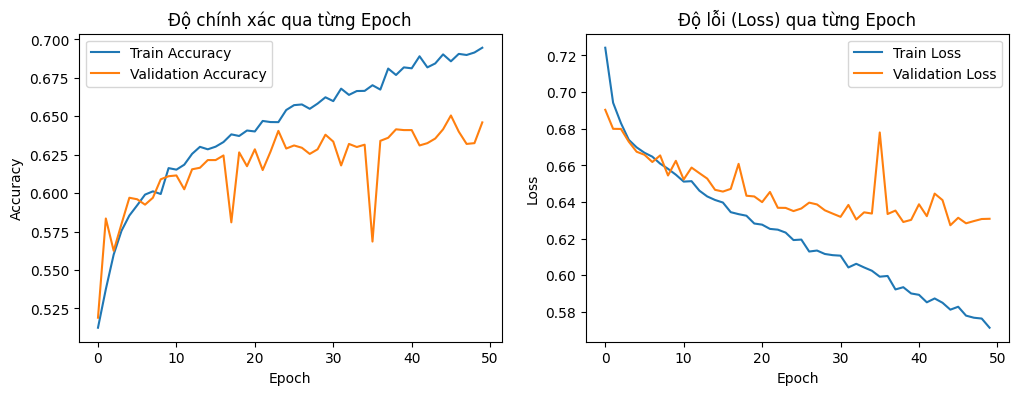

In [44]:
import matplotlib.pyplot as plt

# Tạo một khung ảnh gồm 2 biểu đồ nằm cạnh nhau
plt.figure(figsize=(12, 4))

# --- Biểu đồ 1: Độ chính xác (Accuracy) ---
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy') # Đổi nhãn cho rõ ràng hơn
plt.title('Độ chính xác qua từng Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# --- Biểu đồ 2: Độ lỗi (Loss) ---
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss') # Đổi nhãn cho rõ ràng hơn
plt.title('Độ lỗi (Loss) qua từng Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

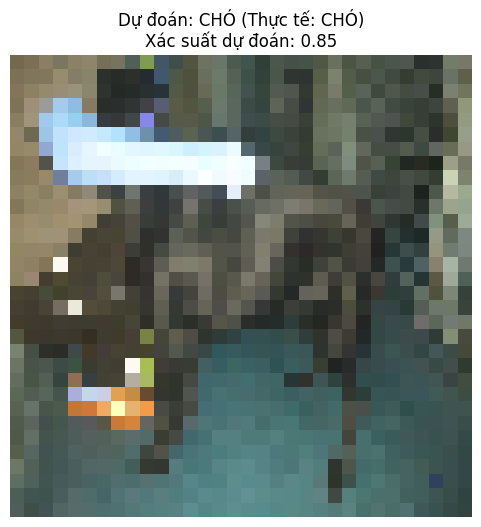

================ KẾT QUẢ DỰ ĐOÁN CHO ẢNH NÀY ================
🤖 Mô hình dự đoán đây là: CHÓ (Xác suất: 0.85)
🖼️ Thực tế tấm ảnh đó là: CHÓ


In [63]:
import numpy as np
import matplotlib.pyplot as plt
import random

# BƯỚC 1: Định nghĩa danh sách 2 nhãn cho chó và mèo (giống như trước)
class_names = ['mèo', 'chó']

# BƯỚC 2: Chọn ngẫu nhiên một tấm ảnh từ tập dữ liệu KIỂM TRA (X_test)
# Bạn có thể thay đổi cách chọn để tập trung vào các ảnh cụ thể nếu muốn
random_index = random.randint(0, len(X_test) - 1)

# Để hiển thị ảnh, chúng ta vẫn cần ảnh gốc 3D từ X_test
test_image_display_comparison = X_test[random_index]

# Để dự đoán, chúng ta cần ảnh đã làm phẳng từ X_test_flat
# Phải đảm bảo test_image_for_prediction có kích thước batch dimension (thêm một chiều)
test_image_for_prediction_comparison = X_test_flat[random_index:random_index+1]

# BƯỚC 3: Đưa ảnh vào mạng để dự đoán xác suất
prediction_comparison = animal_model.predict(test_image_for_prediction_comparison, verbose=0)

# BƯỚC 4: Lấy vị trí (index) có phần trăm xác suất cao nhất
predicted_label_idx_comparison = np.argmax(prediction_comparison)
true_label_idx_comparison = y_test[random_index][0]

# BƯỚC 5: Hiển thị ảnh và kết quả dự đoán
plt.figure(figsize=(6, 6))
plt.imshow(test_image_display_comparison.astype('uint8')) # Đảm bảo ảnh ở định dạng hiển thị
plt.title(f"Dự đoán: {class_names[predicted_label_idx_comparison].upper()} (Thực tế: {class_names[true_label_idx_comparison].upper()})\nXác suất dự đoán: {prediction_comparison[0][predicted_label_idx_comparison]:.2f}")
plt.axis('off')
plt.show()

print("================ KẾT QUẢ DỰ ĐOÁN CHO ẢNH NÀY ================")
print(f"🤖 Mô hình dự đoán đây là: {class_names[predicted_label_idx_comparison].upper()} (Xác suất: {prediction_comparison[0][predicted_label_idx_comparison]:.2f})")
print(f"🖼️ Thực tế tấm ảnh đó là: {class_names[true_label_idx_comparison].upper()}")
print("==========================================================")